Григорьев Алексей, 737-01, Проект по DS
Датасет: Heart analysis

About Dataset
❤️ Heart Disease Dataset

📌 Overview

This dataset contains clinical and demographic information of 303 patients and is commonly used for heart disease prediction and classification tasks. The goal is to predict whether a patient has heart disease based on multiple medical attributes.

It is suitable for:

Binary classification

Feature selection experiments

Model comparison and evaluation

Educational and research purposes

📊 Dataset Information:

Number of instances: 303

Number of features: 13

Target variable: output (binary)

🧬 Feature Description

Feature Description
age Age of the patient
sex Sex (1 = male, 0 = female)
cp Chest pain type (0–3)
trtbps Resting blood pressure (mm Hg)
chol Serum cholesterol (mg/dl)
fbs Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
restecg Resting electrocardiographic results (0–2)
thalachh Maximum heart rate achieved
exng Exercise-induced angina (1 = yes, 0 = no)
oldpeak ST depression induced by exercise
slp Slope of the peak exercise ST segment
caa Number of major vessels colored by fluoroscopy (0–3)
thall Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect)
output Heart disease status (1 = disease, 0 = no disease)

🎯 Target Variable

output = 1 → Patient has heart disease

output = 0 → Patient does not have heart disease

🚀 Possible Use Cases

Heart disease prediction

Feature selection method comparison

Supervised machine learning models (Logistic Regression, SVM, Random Forest, etc.)

Model interpretability and medical data analysis

📚 Notes

The dataset contains no missing values

Features include both numerical and categorical variables

Often used as a benchmark dataset in healthcare ML studies

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [34]:
df = pd.read_csv('heart.csv')

#Размер датасета
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

#Типы данных и пропуски
print("\nИнформация о датасете:")
print(df.info())

Размер датасета: 303 строк, 14 столбцов

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


Пропуски - отсутствуют

Если бы были - заполняли бы средним (при норм. распределении), медианой (при выбросах) или модой (категориальные признаки)

Все признаки - числовые (нет строковых)




In [3]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


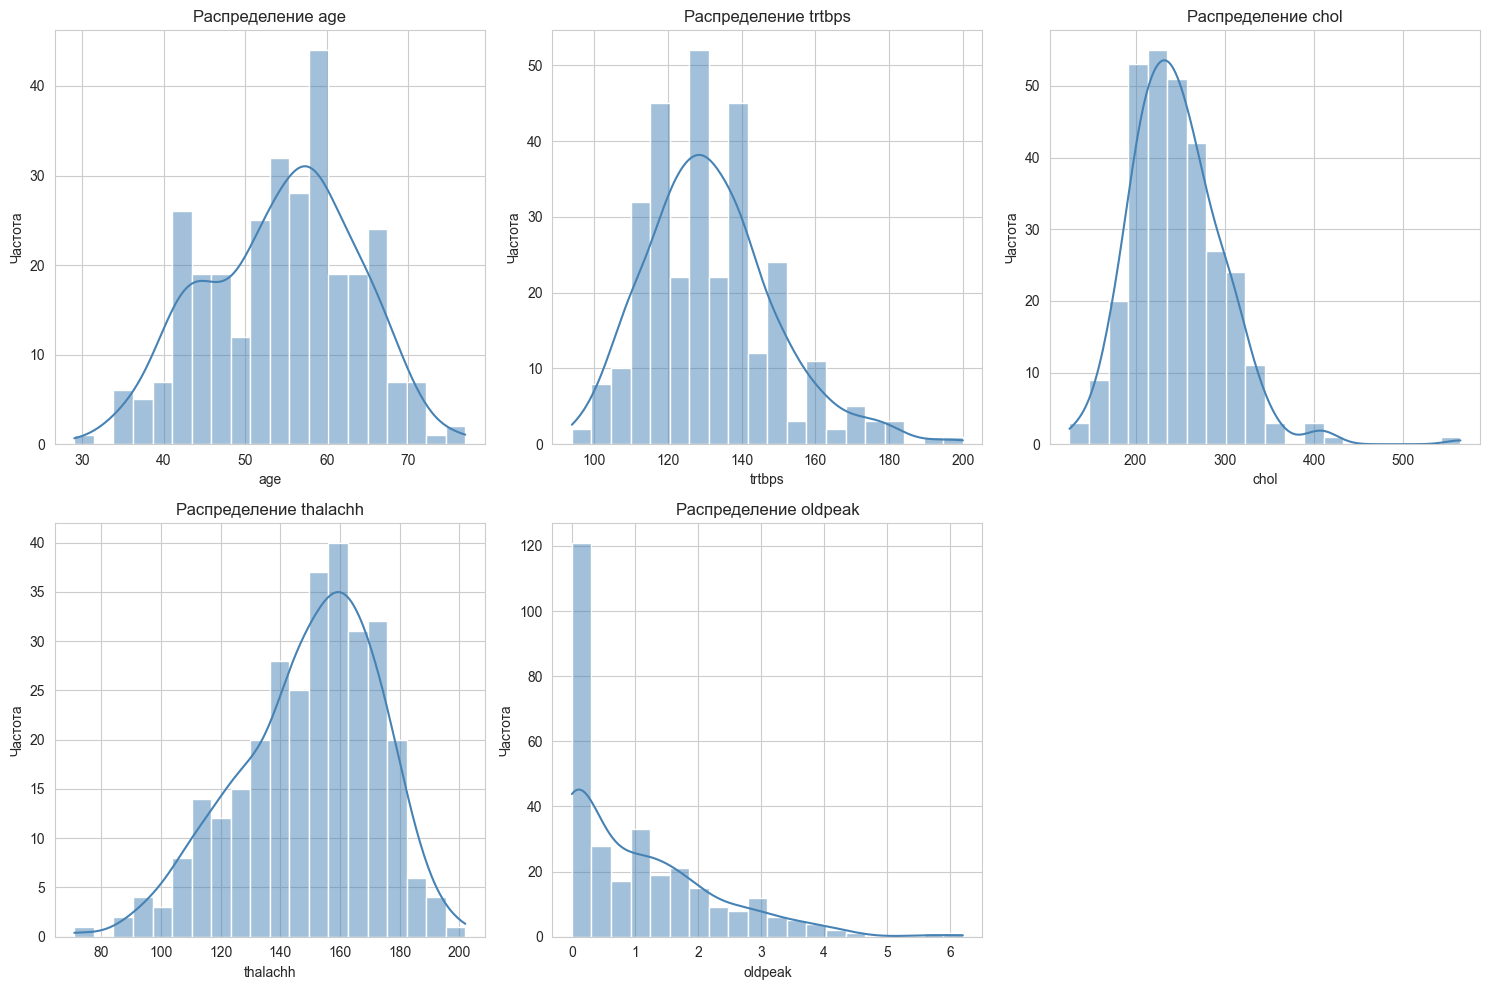

In [7]:
# Список ключевых показателей (непрерывные / псевдо-непрерывные)
continuous_features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. ГИСТОГРАММЫ
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=20)
    axes[i].set_title(f'Распределение {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

# Убираем лишний пустой подграфик (если features меньше 6)
if len(continuous_features) < 6:
    for j in range(len(continuous_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


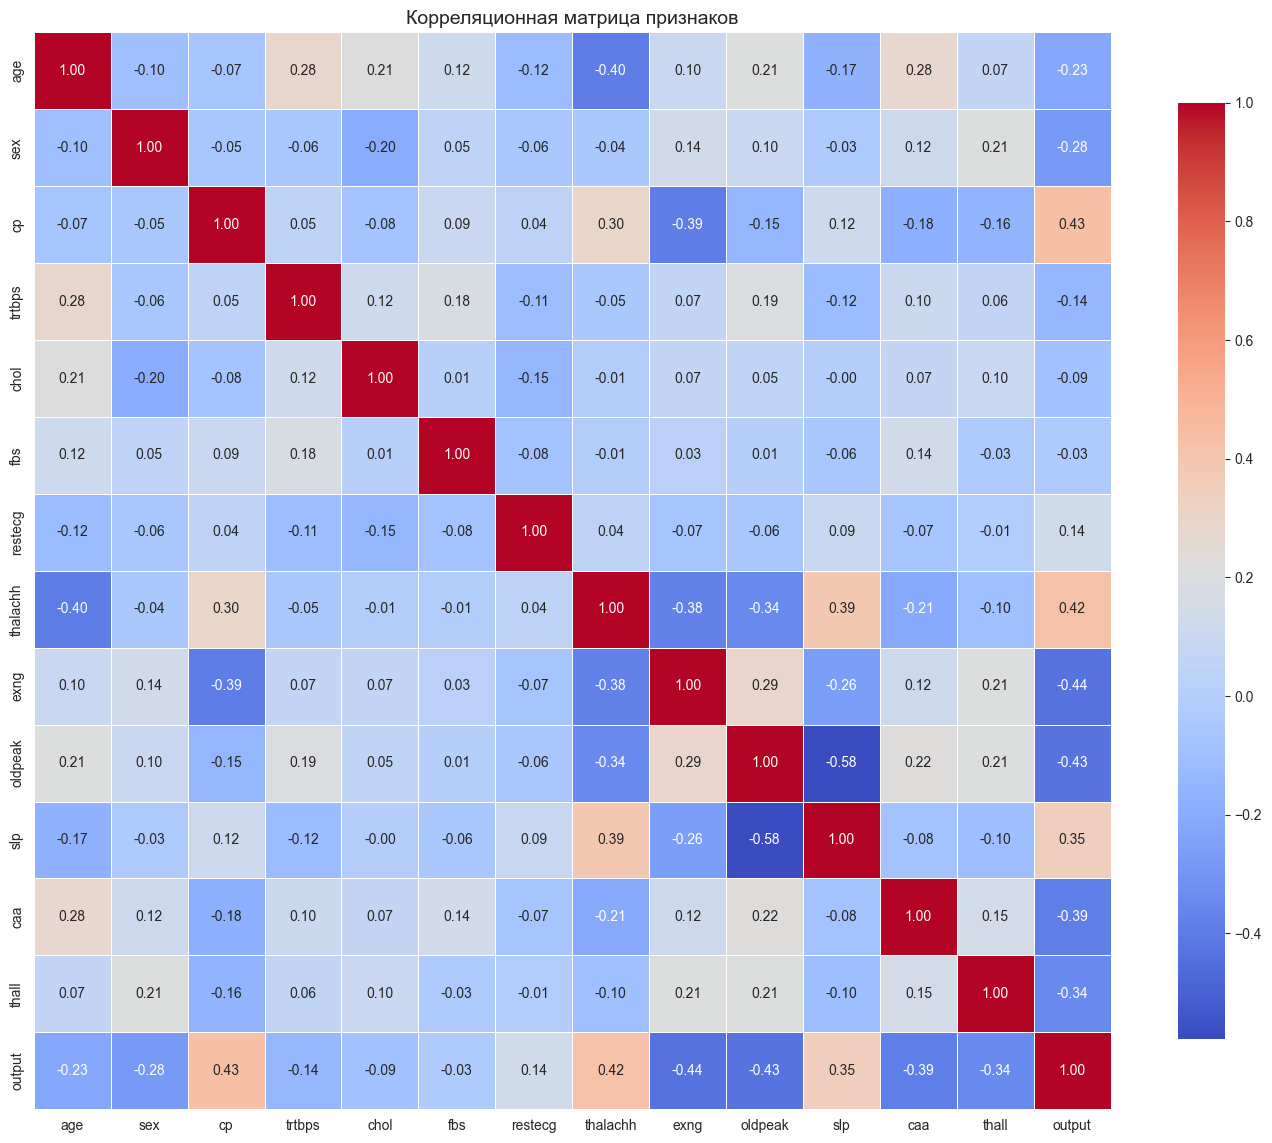

Корреляции признаков с target (output):
output      1.000000
cp          0.433798
thalachh    0.421741
slp         0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trtbps     -0.144931
age        -0.225439
sex        -0.280937
thall      -0.344029
caa        -0.391724
oldpeak    -0.430696
exng       -0.436757
Name: output, dtype: float64


In [8]:
# 2. КОРРЕЛЯЦИОННАЯ МАТРИЦА
# Берём все числовые признаки (в датасете все int/float, можно всю таблицу)
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Дополнительно: вывести топ-5 корреляций с целевой переменной 'output'
print("Корреляции признаков с target (output):")
print(corr_matrix['output'].sort_values(ascending=False))

Изучим датасет на выбросы

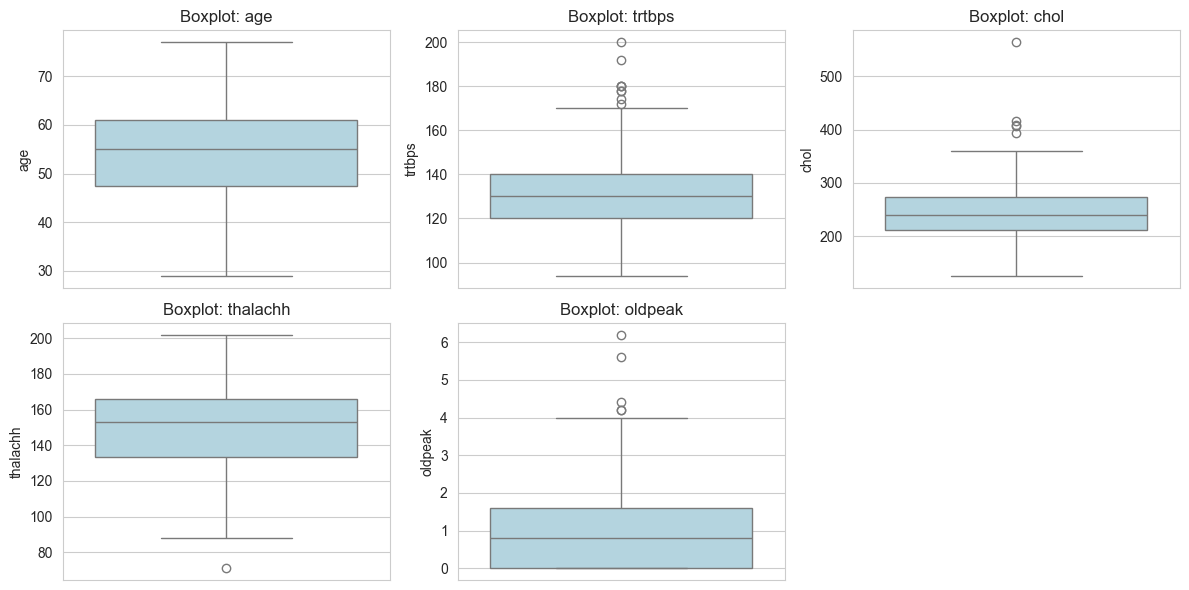

age: нижняя граница = 27.25, верхняя = 81.25, выбросов = 0
trtbps: нижняя граница = 90.00, верхняя = 170.00, выбросов = 9
chol: нижняя граница = 115.75, верхняя = 369.75, выбросов = 5
thalachh: нижняя граница = 84.75, верхняя = 214.75, выбросов = 1
oldpeak: нижняя граница = -2.40, верхняя = 4.00, выбросов = 5

Примеры выбросов для chol:
     age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
28    65    0   2     140   417    1        0       157     0      0.8    2   
85    67    0   2     115   564    0        0       160     0      1.6    1   
96    62    0   0     140   394    0        0       157     0      1.2    1   
220   63    0   0     150   407    0        0       154     0      4.0    1   
246   56    0   0     134   409    0        0       150     1      1.9    1   

     caa  thall  output  
28     1      2       1  
85     0      3       1  
96     0      2       1  
220    3      3       0  
246    2      3       0  


In [9]:
cont_features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

# 1. Boxplot'ы для визуального анализа
plt.figure(figsize=(12, 6))
for i, col in enumerate(cont_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# 2. Количество выбросов по методу IQR
outliers_count = {}
for col in cont_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_count[col] = len(outliers)
    print(f"{col}: нижняя граница = {lower:.2f}, верхняя = {upper:.2f}, выбросов = {len(outliers)}")

# 3. Показать строки с выбросами (например, для chol)
print("\nПримеры выбросов для chol:")
print(df[df['chol'] > (df['chol'].quantile(0.75) + 1.5 * (df['chol'].quantile(0.75)-df['chol'].quantile(0.25)))].head())

Выбор признаков и создание метки доклинического риска

In [25]:
# 2. Выбираем признаки (только непрерывные)
features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
X = df[features]

# 3. Создаём метку доклинического риска (preclinical_risk)
#    (oldpeak > 1.0) И (thalachh < 150) И (chol < 240)
df['preclinical_risk'] = ((df['oldpeak'] > 1.0) & 
                          (df['thalachh'] < 150) & 
                          (df['chol'] < 240)).astype(int)

Стандартизация

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Стандартизированные данные (первые 5 строк):")
print(X_scaled.head())
print(f"\nСредние после стандартизации: {X_scaled.mean().mean():.2e}")
print(f"Стандартные отклонения после стандартизации: {X_scaled.std().mean():.2f}")

Стандартизированные данные (первые 5 строк):
       age   trtbps     chol  thalachh  oldpeak
0  0.95220  0.76396 -0.25633   0.01544  1.08734
1 -1.91531 -0.09274  0.07220   1.63347  2.12257
2 -1.47416 -0.09274 -0.81677   0.97751  0.31091
3  0.18017 -0.66387 -0.19836   1.23990 -0.20671
4  0.29046 -0.66387  2.08205   0.58394 -0.37924

Средние после стандартизации: -2.85e-16
Стандартные отклонения после стандартизации: 1.00


PCA c 3 компонентами

In [27]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_scaled)

df['PC1'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]
df['PC3'] = pca_result[:, 2]

Доля объясненной дисперсии

In [28]:
explained_variance = pca.explained_variance_ratio_
print(f"\nДоля объяснённой дисперсии каждой компоненты: {explained_variance}")
print(f"Суммарная дисперсия первых двух компонент: {explained_variance[:2].sum():.3f}")
print(f"Суммарная дисперсия первых трёх компонент: {explained_variance.sum():.3f}")


Доля объяснённой дисперсии каждой компоненты: [0.36131509 0.21550951 0.17667531]
Суммарная дисперсия первых двух компонент: 0.577
Суммарная дисперсия первых трёх компонент: 0.753


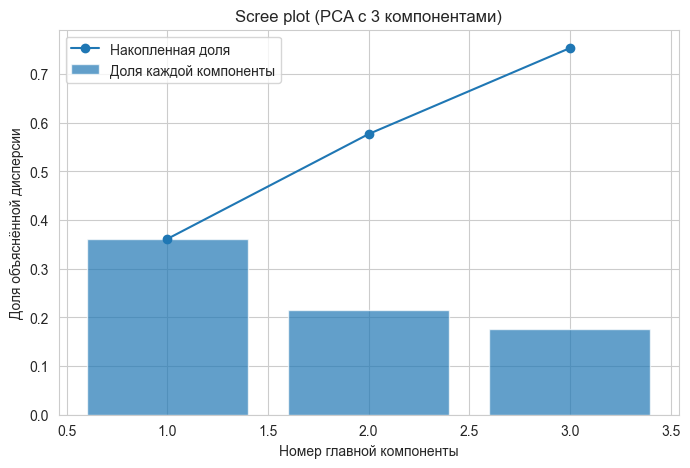

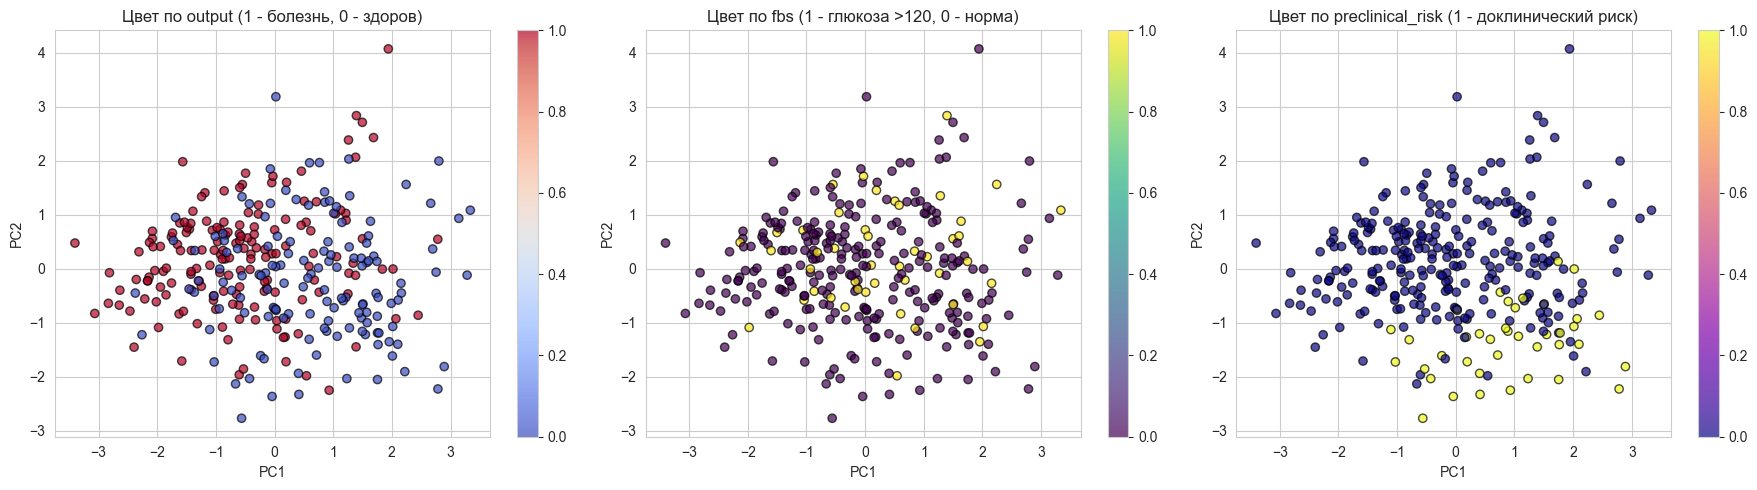

In [29]:

# 7. График объяснённой дисперсии (scree plot)
plt.figure(figsize=(8,5))
plt.bar(range(1,4), explained_variance, alpha=0.7, label='Доля каждой компоненты')
plt.plot(range(1,4), np.cumsum(explained_variance), marker='o', label='Накопленная доля')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Scree plot (PCA с 3 компонентами)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Проекция PC1 vs PC2 с раскраской по трём критериям
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Раскраска по output
scatter1 = axes[0].scatter(df['PC1'], df['PC2'], c=df['output'], cmap='coolwarm', alpha=0.7, edgecolors='k')
axes[0].set_title('Цвет по output (1 - болезнь, 0 - здоров)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# Раскраска по fbs
scatter2 = axes[1].scatter(df['PC1'], df['PC2'], c=df['fbs'], cmap='viridis', alpha=0.7, edgecolors='k')
axes[1].set_title('Цвет по fbs (1 - глюкоза >120, 0 - норма)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# Раскраска по preclinical_risk
scatter3 = axes[2].scatter(df['PC1'], df['PC2'], c=df['preclinical_risk'], cmap='plasma', alpha=0.7, edgecolors='k')
axes[2].set_title('Цвет по preclinical_risk (1 - доклинический риск)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

In [30]:
# 1. Определяем порог PC1 как 90-й перцентиль
threshold_pc1 = df['PC1'].quantile(0.90)
print(f"90-й перцентиль PC1: {threshold_pc1:.3f}")

# 2. Отбираем пациентов с высоким PC1 (> порога) и нормальными показателями
#    Нормальные показатели: значения ниже 75-го перцентиля по каждому признаку
q_chol = df['chol'].quantile(0.75)
q_trtbps = df['trtbps'].quantile(0.75)
q_oldpeak = df['oldpeak'].quantile(0.75)

high_pc1_normal = df[
    (df['PC1'] > threshold_pc1) &
    (df['chol'] < q_chol) &
    (df['trtbps'] < q_trtbps) &
    (df['oldpeak'] < q_oldpeak)
]

print(f"Пороги (75-й перцентиль): chol < {q_chol:.1f}, trtbps < {q_trtbps:.1f}, oldpeak < {q_oldpeak:.2f}")
    
print(f"\nПациентов с высоким PC1 и нормальными отдельными показателями: {len(high_pc1_normal)}")
print(f"Из них с preclinical_risk = 1: {high_pc1_normal['preclinical_risk'].sum()}")

90-й перцентиль PC1: 1.750
Пороги (75-й перцентиль): chol < 274.5, trtbps < 140.0, oldpeak < 1.60

Пациентов с высоким PC1 и нормальными отдельными показателями: 2
Из них с preclinical_risk = 1: 0


In [39]:
# 3. Сравнение с preclinical_risk (сколько совпадает)
#    Preclinical_risk = 1 означает (oldpeak > 1.0) & (thalachh < 150) & (chol < 240)
#    Но наши отфильтрованные имеют oldpeak < 1.0, поэтому они НЕ могут иметь preclinical_risk = 1 по определению.
#    Это важно: наш доклинический риск по определению требует oldpeak > 1.0, а здесь oldpeak < 1.0.
#    Значит, эти пациенты не попадают в preclinical_risk, но возможно, у них есть другой тип риска.
#    Поэтому логично создать новую метку "скрытый риск" - высокий PC1, но нормальные показатели.

print("\nПримечание: наши отфильтрованные пациенты имеют oldpeak < 1.0, поэтому по исходному определению preclinical_risk=0.")
print("Это логично: они имеют высокую PC1, но без явных отклонений по старым критериям - это и есть 'доклинические нарушения'.")

# 4. Выводим 3 примера таких пациентов (если есть)
if len(high_pc1_normal) >= 3:
    examples = high_pc1_normal.head(3)
    print("\nТри примера пациентов с высоким PC1 и нормальными отдельными показателями:\n")
    for idx, row in examples.iterrows():
        print(f"Пациент {idx}:")
        print(f"  Возраст: {row['age']}, пол: {'Муж' if row['sex']==1 else 'Жен'}")
        print(f"  Давление: {row['trtbps']}, холестерин: {row['chol']}, oldpeak: {row['oldpeak']}")
        print(f"  PC1 = {row['PC1']:.3f} (порог {threshold_pc1:.3f})")
        print(f"  Болезнь сердца (output): {row['output']}")
        print(f"  Глюкоза >120 (fbs): {row['fbs']}")
        print(f"  Созданный preclinical_risk: {row['preclinical_risk']}")
        print("-" * 50)
else:
    print(f"\nНайдено только {len(high_pc1_normal)} пациентов")
    print("Выводим всех:")
    for idx, row in high_pc1_normal.iterrows():
        print(f"Пациент {idx}: возраст {row['age']}, PC1={row['PC1']:.3f}, output={row['output']}")


Примечание: наши отфильтрованные пациенты имеют oldpeak < 1.0, поэтому по исходному определению preclinical_risk=0.
Это логично: они имеют высокую PC1, но без явных отклонений по старым критериям - это и есть 'доклинические нарушения'.

Найдено только 2 пациентов
Выводим всех:
Пациент 216: возраст 62.0, PC1=1.751, output=0.0
Пациент 272: возраст 67.0, PC1=2.220, output=0.0
